In [265]:
import warnings
warnings.filterwarnings('ignore')
from typing import Any, Dict, List, Optional, Tuple
from IPython.display import display

In [266]:
%pip install yfinance matplotlib pandas seaborn numpy


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Veriyi yfinance den çekeceğiz
kullanacağımız veriler bilanço rapor sonuçları ve günlük hisse fiyatlamaları

In [ ]:
SECTOR_TICKERS: Dict[str, List[str]] = {
    "Semicondutor": ["AMD", "INTC", "MU", "NVDA", "QCOM", "TXN"],
    "Tech_Cloud": ["MSFT", "GOOGL", "AMZN", "META"],
    "Energy": ["XOM", "CVX"]
}

ALL_STOCKS = sorted({t for v in SECTOR_TICKERS.values() for t in v})
# ALL_STOCKS = ["AMD", "INTC", "MU", "NVDA", "QCOM", "TXN", "MSFT", "GOOGL", "AMZN", "META", "XOM", "CVX"]
ALL_EVENT_TICKERS = list(ALL_STOCKS)

In [268]:
import pandas as pd
import yfinance as yf

def download_ohlcv(
    tickers: List[str],
    progress: bool = True
) -> pd.DataFrame:
    """Multi-index colums (field, ticker): Adj Close, Close, Volume."""
    data = yf.download(
        tickers=tickers,
        period="max",
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        threads=True,
        progress=progress
    )
    if isinstance(data.columns, pd.MultiIndex):
        return data

    t = tickers[0]
    out = pd.concat({t: data}, axis=1)
    out.columns = pd.MultiIndex.from_tuples([(t.c) for c in data.columns]) 
    return out 

In [269]:
raw_stock_data = download_ohlcv(ALL_EVENT_TICKERS)

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AMD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [270]:
def wide_adj_close_volume(df: pd.DataFrame) -> Tuple[pd.DataFrame]:

    if isinstance(df.columns, pd.MultiIndex) and df.columns.nlevels == 2:
        fields = df.columns.get_level_values(1).unique().tolist()
        price_key = "Adj Close" if "Adj Close" in fields else "Close"
        adj = df.xs(price_key, axis=1, level=1)
        vol = df.xs("Volume", axis=1, level=1)
        return adj, vol
    raise ValueError("Unexpected YFinance Shape")

In [271]:
adj, vol = wide_adj_close_volume(raw_stock_data)

In [272]:
adj = adj.sort_index()

In [273]:
adj.index = pd.to_datetime(adj.index).tz_localize(None).normalize()

In [274]:
vol = vol.reindex(adj.index).sort_index()

In [275]:
rets = adj.pct_change(periods=1)

In [ ]:
def ticker_sector_map() -> Dict[str, str]:
    m: Dict[str,str] = {}
    for sector, tickers in SECTOR_TICKERS.items():
        for t in tickers:
            m[t] = sector
    return m


In [277]:
tmap = ticker_sector_map()

In [278]:
def _universe_cols(adj: pd.DataFrame) -> List[str]:
    return [c for c in ALL_EVENT_TICKERS if c in adj.columns]

def market_basket_close(adj : pd.DataFrame) -> pd.Series:
    cols = _universe_cols(adj) 
    if not cols:
        raise ValueError("No Universe Columns in adj")
    return adj[cols].mean(axis=1, skipna=True)

In [279]:
event_tickers = _universe_cols(adj)
market = market_basket_close(adj)

yukardaki veri o gün market ortalamasının yüzde kaç arttığını gösteriyor

In [280]:
def get_earnings_history(ticker: str, limit: int=40) -> pd.DataFrame:
    t = yf.Ticker(ticker)
    rows = []
    try:
        q = t.get_earnings_dates(limit=limit)
        if q is not None and len(q):
            q = q.copy()
            q["ticker"] = ticker
            rows.append(q)
    except Exception:
        pass
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows)
    out.index = pd.to_datetime(out.index).tz_localize(None).normalize()
    out = out.sort_index()
    return out

In [281]:
def sector_peer_basket_close(adj: pd.DataFrame, sector: str, ticker: str) -> pd.Series:
    peers = [x for x in SECTOR_TICKERS[sector] if x != ticker and x in adj.columns]
    if peers:
        return adj[peers].mean(axis = 1, skipna=True)
    return market_basket_close(adj)


In [282]:
import numpy as np

def add_technical_features(
    close: pd.Series,
    volume: pd.Series,
    market_close: pd.Series,
    sector_close: pd.Series,
) -> pd.DataFrame:
    from ta.momentum import RSIIndicator, ROCIndicator
    from ta.trend import MACD

    df = pd.DataFrame({"close": close, "vol": volume}).sort_index()
    mkt_c = market_close.reindex(df.index)
    sec_c = sector_close.reindex(df.index)
    eps = 1e-8 # Stabil bir epsilon değeri

    # Fiyat Getirileri (Price Returns)
    df["ret_1d"] = df["close"].pct_change()
    for w in (2, 3, 5, 10, 20, 60):
        df[f"ret_{w}d"] = df["close"].pct_change(w)

    # Tarihsel Oynaklık (Volatility / Standard Deviation)
    for w in (5, 10, 20, 60):
        df[f"vol_std_{w}"] = df["ret_1d"].rolling(w).std()

    # Yüzde değişim matematiksel olarak asimetriktir ve yönü saptırır. Logaritmik değişim ise simetriktir.
    # Log transform kullanarak modele "Bugün hacimde olağanüstü bir patlama oldu ama sakin ol,
    # bu sadece çok güçlü bir alış/satış ilgisi anlamına geliyor,
    # katsayılarını havaya uçurmana gerek yok" mesajını vermiş oluyoruz.
    df["vol_chg_log"] = np.log((df["vol"] + eps) / (df["vol"].shift(1) + eps))
    vol_ma20 = df["vol"].rolling(20).mean()
    vol_std20 = df["vol"].rolling(20).std()
    df["vol_ratio_20"] = df["vol"] / (vol_ma20 + eps)
    df["abnormal_vol_z"] = (df["vol"] - vol_ma20) / (vol_std20 + eps)

    # RSI, bir hisse senedinin aşırı alınıp alınmadığını (overbought) veya aşırı satılıp satılmadığını (oversold) gösteren bir momentum osilatörüdür. Değeri her zaman 0 ile 100 arasındadır.
	# RSI > 70: Hisse çok hızlı yükselmiş, "aşırı alınmış" ve kar satışları gelebilir.
	# RSI < 30: Hisse çok sert düşmüş, "aşırı satılmış" ve tepki alımları gelebilir.
    rsi = RSIIndicator(df["close"], window=14)
    df["rsi_14"] = rsi.rsi()

    # MACD, hem trendin yönünü hem de momentumunu aynı anda gösteren bir indikatördür. İki farklı hareketli ortalamanın arasındaki ilişkiyi inceler.
	# macd() (MACD Çizgisi): Trendin yönünü ve gücünü gösterir.
	# macd_signal() (Sinyal Çizgisi): MACD çizgisinin kendi hareketli ortalamasıdır. MACD, sinyal çizgisini yukarı kestiğinde "Al", aşağı kestiğinde "Sat" sinyali üretilir.
    macd = MACD(df["close"])
    df["macd_norm"] = macd.macd() / (df["close"] + eps)
    df["macd_signal_norm"] = macd.macd_signal() / (df["close"] + eps)

    # ROC, fiyatın saf hızını ölçer. Mevcut fiyatın, N gün önceki (kodunuzda window=10 gün) fiyata göre yüzde kaç değiştiğini gösteren katıksız bir momentum indikatörüdür.
	# Merkez çizgisi 0'dır. ROC sıfırın üzerindeyse fiyat yukarı yönlü hızlanıyor, altındaysa aşağı yönlü hızlanıyordur.
    roc = ROCIndicator(df["close"], window=10)
    df["roc_10"] = roc.roc()

    # SMA (Simple Moving Average - Basit Hareketli Ortalama),
    # finansal piyasalarda fiyat verisindeki anlık dalgalanmaları (gürültüyü) temizlemek
    # ve ana trendin yönünü net bir şekilde görmek için kullanılan en temel teknik analiz aracıdır.
    for w in (20, 50, 200):
        ma = df["close"].rolling(w).mean()
        df[f"dist_sma_{w}"] = (df["close"] - ma) / (ma + eps)

    # "Market", genellikle ülkenin veya piyasanın ana endeksidir
    df["mkt_ret_1d"] = mkt_c.pct_change()
    df["mkt_ret_5d"] = mkt_c.pct_change(5)

    # "Sektör", genellikle ülkenin veya piyasanın ana endeksidir
    df["sector_ret_1d"] = sec_c.pct_change()
    df["sector_ret_5d"] = sec_c.pct_change(5)

    # Hisse senedinin günlük getirileri ile ait olduğu sektör endeksinin günlük getirileri arasındaki 60 günlük (yaklaşık 3 aylık) doğrusal ilişkiyi ölçer. Değeri her zaman -1 ile +1 arasındadır.
	# +1'e Yakın Değerler (Yüksek Korelasyon): Hisse, sektörüyle neredeyse tamamen senkronize hareket ediyordur. Sektör yükselirken yükselir, düşerken düşer. Genellikle sektörün devleri (lokomotif hisseler) veya endeksi birebir takip eden hisseler bu gruptadır.
	# 0'a Yakın Değerler (Korelasyonsuz): Hisse, sektör endeksinden tamamen bağımsız hareket ediyordur. Sektör çökerken bu hisse kendi özel bir haberiyle (örneğin yeni bir patent, devasa bir ihale) yükselebilir.
	# -1'e Yakın Değerler (Ters Korelasyon): Hisse sektörüyle zıt yönlerde hareket ediyordur (Hisse senetlerinde nadir görülür, daha çok defansif veya hedge amaçlı varlıklarda rastlanır).
    df["roll_corr_stock_sector_60"] = df["ret_1d"].rolling(60).corr(df["sector_ret_1d"])

    return df

In [283]:
def next_trading_day(index: pd.DatetimeIndex, ref: pd.Timestamp) -> Optional[pd.Timestamp]:
    idx = index.sort_values()
    pos = idx.searchsorted(pd.Timestamp(ref).normalize(), side="right")
    if pos >= len(idx):
        return None
    return idx[pos]

In [284]:
def prev_trading_day(index: pd.DatetimeIndex, ref: pd.Timestamp) -> Optional[pd.Timestamp]:
    idx = index.sort_values()
    pos = idx.searchsorted(pd.Timestamp(ref).normalize(), side="left")
    if pos == 0:
        return None
    return idx[pos - 1]

In [285]:
HORIZON_DAYS: Dict[str, int] = {
    "y_1d": 1,
    "y_3d": 3,
    "y_1w": 5,
    "y_2w": 10,
    "y_3w": 15,
    "y_1m": 21,
    "y_3m": 63,
}

In [286]:
def trading_day_offset(
    index: pd.DatetimeIndex, day: pd.Timestamp, offset: int
) -> Optional[pd.Timestamp]:
    """Return date at `offset` trading steps from `day` (day must exist in index). offset>0 = forward."""
    idx = pd.DatetimeIndex(sorted(pd.DatetimeIndex(index).unique()))
    day = pd.Timestamp(day).normalize()
    loc = int(idx.get_indexer([day], method="pad")[0])
    if loc < 0 or loc >= len(idx) or idx[loc] != day:
        return None
    j = loc + offset
    if j >= len(idx):
        return None
    return pd.Timestamp(idx[j])

In [287]:

import numpy as np

def build_event_table(
    ticker: str,
    sector: str,
    close: pd.Series,
    volume: pd.Series,
    full_index: pd.DatetimeIndex,
    market_close: pd.Series,
    sector_peer_close: pd.Series,
    earnings_df: pd.DataFrame,
) -> pd.DataFrame:
    tech = add_technical_features(close, volume, market_close, sector_peer_close)

    events = []
    if earnings_df is None or earnings_df.empty:
        return pd.DataFrame()

    for dt, row in earnings_df.iterrows():
        dt = pd.Timestamp(dt).normalize()
        entry = next_trading_day(full_index, dt)
        if entry is None:
            continue
        feat_day = prev_trading_day(full_index, entry)
        if feat_day is None or feat_day not in tech.index:
            continue
        feats = tech.loc[feat_day].copy()
        # earnings-based features
        eps_est = row.get("EPS Estimate", np.nan)
        eps_act = row.get("Reported EPS", np.nan)
        surprise = np.nan
        if pd.notna(eps_est) and pd.notna(eps_act) and eps_est != 0:
            surprise = (eps_act - eps_est) / (abs(eps_est) + 1e-9)
        feats_dict = feats.to_dict()
        feats_dict.update(
            {
                "ticker": ticker,
                "sector": sector,
                "event_date": dt,
                "entry_date": entry,
                "feature_date": feat_day,
                "eps_estimate": eps_est,
                "eps_reported": eps_act,
                "eps_surprise_pct": surprise,
                "eps_beat": int(
                    pd.notna(eps_est)
                    and pd.notna(eps_act)
                    and (eps_act > eps_est)
                ),
            }
        )
        # forward returns from entry close to entry + h
        base_px = float(close.loc[entry])
        if not np.isfinite(base_px) or base_px == 0:
            continue
        for col, h in HORIZON_DAYS.items():
            fut = trading_day_offset(full_index, entry, h)
            if fut is None or fut not in close.index:
                feats_dict[col] = np.nan
                continue
            px = float(close.loc[fut])
            feats_dict[col] = (px / base_px) - 1.0
        events.append(feats_dict)

    return pd.DataFrame(events)

In [288]:
def attach_historical_earnings_features(events: pd.DataFrame) -> pd.DataFrame:
    """Rolling past surprise / post-event drift (same ticker, prior rows)."""
    if events.empty:
        return events
    ev = events.sort_values(["ticker", "entry_date"]).copy()
    g = ev.groupby("ticker", group_keys=False)
    ev["surprise_lag1"] = g["eps_surprise_pct"].shift(1)
    # Mevsimsellik Etkisi: Bazı şirketlerin işleri yapısal olarak belirli çeyreklerde çok daha iyi olur (örneğin perakendeciler için yılbaşı dönemini içeren Q4, turizm şirketleri için Q3). 
    # Son 4 çeyreği dahil etmek, bu mevsimsel dalgalanmaları yumuşatır (smooth eder) ve daha dengeli bir baz çizgisi sunur.
    # Şirketin son 1 yılda analist beklentilerini aşma (veya altında kalma) eğilimini gösterir.
    # Sürekli pozitif sürpriz yapan bir şirket "momentum" kazanmış demektir.
    ev["surprise_roll4_mean"] = g["eps_surprise_pct"].transform(
        lambda s: s.shift(1).rolling(4, min_periods=1).mean()
    )
    for c in list(HORIZON_DAYS.keys()):
		# Şirketin geçmiş 4 bilançodaki etkinlik sonrası hareket (post-earnings announcement drift - PEAD) ortalamasıdır. 
		# Piyasanın bu hissede bilanço sonrası nasıl tepki verdiğine dair (örneğin, "genelde ilk gün yükselip sonraki günlerde yataya mı sarıyor?") 1 yıllık bir davranış kalıbı sunar.
        ev[f"prior_post_{c}_mean4"] = g[c].transform(
            lambda s: s.shift(1).rolling(4, min_periods=1).mean()
        )
    return ev

In [289]:
def assemble_dataset(
    progress: bool = False,
    earnings_limit: int = 60,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    tickers = ALL_EVENT_TICKERS
    raw = download_ohlcv(tickers, progress=progress)
    adj, vol = wide_adj_close_volume(raw)
    adj = adj.sort_index()
    adj.index = pd.to_datetime(adj.index).tz_localize(None).normalize()
    vol = vol.reindex(adj.index).sort_index()
    rets = adj.pct_change()

    tmap = ticker_sector_map()
    market = market_basket_close(adj)
    event_tickers = [t for t in ALL_EVENT_TICKERS if t in adj.columns]

    earnings_map = {}
    for t in event_tickers:
        earnings_map[t] = get_earnings_history(t, limit=earnings_limit)

    frames = []
    if event_tickers:
        assert earnings_map is not None
    for t in event_tickers:
        sector = tmap[t]
        peer = sector_peer_basket_close(adj, sector, t)
        edf = earnings_map[t]  # type: ignore[index]
        ev = build_event_table(
            ticker=t,
            sector=sector,
            close=adj[t],
            volume=vol[t],
            full_index=adj.index,
            market_close=market,
            sector_peer_close=peer,
            earnings_df=edf,
        )
        if not ev.empty:
            frames.append(ev)
    events = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    events = attach_historical_earnings_features(events)
    if not events.empty:
        num_cols = events.select_dtypes(include=[np.number]).columns
        events[num_cols] = events[num_cols].replace([np.inf, -np.inf], np.nan)
    return events, adj, rets

In [290]:
events, adj, rets = assemble_dataset()
print("events", events.shape, "adj", adj.shape)


1 Failed download:
['AMD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


events (0, 0) adj (0, 1)


In [291]:
ev_chrono = events.sort_values("entry_date")
tab_veri = pd.DataFrame(
    [
        {
            "n_olay": len(events),
            "n_ticker": events["ticker"].nunique(),
            "tarih_min": ev_chrono["entry_date"].min(),
            "tarih_max": ev_chrono["entry_date"].max(),
        }
    ]
)
display(tab_veri)

KeyError: 'entry_date'

In [ ]:
import matplotlib.pyplot as plt

ev_chrono.groupby(ev_chrono["entry_date"].dt.to_period("M")).size().plot(
    kind="bar", figsize=(12, 4), title="Aylık olay sayısı (entry_date)"
)
plt.tight_layout()
plt.show()

NameError: name 'ev_chrono' is not defined

In [ ]:
def target_columns() -> List[str]:
    return list(HORIZON_DAYS.keys())

In [ ]:
_demo_tgt = [c for c in target_columns() if c in events.columns][0]
y_raw = events[_demo_tgt].values
y_sorted = ev_chrono[_demo_tgt].values
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=200)
axes[0].plot(y_raw, ".", alpha=0.5, markersize=3)
axes[0].set_title(f"Sıra: ticker→tarih ({_demo_tgt})")
axes[1].plot(y_sorted, ".", alpha=0.5, markersize=3)
axes[1].set_title(f"Sıra: entry_date ({_demo_tgt})")
plt.tight_layout()
plt.show()

In [ ]:
univ = [c for c in adj.columns]
ret_w = adj[univ].pct_change()


In [ ]:
def slice_returns_calendar_tail(
    returns_wide: pd.DataFrame,
    months: int,
    *,
    end: Optional[pd.Timestamp] = None,
) -> pd.DataFrame:
    """Son `months` takvim ayı içindeki satırlar (end dahil, günlük / işgünü indeks)."""
    df = returns_wide.sort_index()
    if df.empty:
        return df.copy()
    idx = pd.DatetimeIndex(df.index).tz_localize(None).normalize()
    df = df.copy()
    df.index = idx
    end_ts = pd.Timestamp(end if end is not None else df.index.max()).normalize()
    start_ts = (end_ts - pd.DateOffset(months=months)).normalize()
    sub = df.loc[(df.index >= start_ts) & (df.index <= end_ts)]
    return sub.dropna(how="all", axis=0)

# Takvim sonu → geriye N ay (iş günü getiri paneli üzerinde korelasyon)
CORRELATION_CALENDAR_WINDOWS: List[Tuple[str, int]] = [
    ("1m", 1),
    ("2m", 2),
    ("3m", 3),
    ("6m", 6),
    ("9m", 9),
    ("1y", 12),
    ("2y", 24),
]

CORR_WINDOW_TITLE_TR: Dict[str, str] = {
    "1m": "Son 1 ay",
    "2m": "Son 2 ay",
    "3m": "Son 3 ay",
    "6m": "Son 6 ay",
    "9m": "Son 9 ay",
    "1y": "Son 1 yıl",
    "2y": "Son 2 yıl",
}

def correlation_bundle(returns_wide: pd.DataFrame) -> Dict[str, object]:
    corr = returns_wide.corr()
    return {"corr": corr}

def correlation_bundles_by_calendar_windows(
    returns_wide: pd.DataFrame,
    windows: Optional[List[Tuple[str, int]]] = None,
) -> Dict[str, Dict[str, Any]]:
    spec = windows if windows is not None else CORRELATION_CALENDAR_WINDOWS
    out: Dict[str, Dict[str, Any]] = {}
    for key, months in spec:
        sub = slice_returns_calendar_tail(returns_wide, months)
        n = int(len(sub))
        if n < 2:
            out[key] = {"corr": pd.DataFrame(), "n_obs": n, "months": months}
        else:
            b = correlation_bundle(sub)
            out[key] = {**b, "n_obs": n, "months": months}
    return out

corr_bundles = correlation_bundles_by_calendar_windows(ret_w)

win_tab = pd.DataFrame(
    [
        {
            "pencere": CORR_WINDOW_TITLE_TR.get(k, k),
            "ay": v["months"],
            "n_gun": v["n_obs"],
        }
        for k, v in corr_bundles.items()
    ]
)
display(win_tab)

,pencere,ay,n_gun
0,Son 1 ay,1,0
1,Son 2 ay,2,0
2,Son 3 ay,3,0
3,Son 6 ay,6,0
4,Son 9 ay,9,0
5,Son 1 yıl,12,0
6,Son 2 yıl,24,0


In [292]:
import seaborn as sns

for k, meta in corr_bundles.items():
    cmat = meta["corr"]
    ttl = CORR_WINDOW_TITLE_TR.get(k, k) + f" (n={meta['n_obs']} gün)"
    if cmat.empty or cmat.shape[0] < 2:
        print(ttl, "→ yeterli gözlem yok, ısı haritası atlandı")
        continue
    fig, ax = plt.subplots(figsize=(14, 11), dpi=200)
    sns.heatmap(cmat, ax=ax, cmap="vlag", center=0, square=True)
    ax.set_title(f"Getiri korelasyon — {ttl}")
    plt.tight_layout()
    plt.show()

Son 1 ay (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 2 ay (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 3 ay (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 6 ay (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 9 ay (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 1 yıl (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı
Son 2 yıl (n=0 gün) → yeterli gözlem yok, ısı haritası atlandı


In [293]:
for k in ("1y", "2y"):
    meta = corr_bundles.get(k)
    if not meta or meta["corr"].empty or meta["corr"].shape[0] < 2:
        continue
    g = sns.clustermap(
        meta["corr"], cmap="vlag", center=0, figsize=(14, 14)
    )
    g.fig.suptitle(
        f"Clustermap — {CORR_WINDOW_TITLE_TR.get(k, k)}", y=1.02
    )
    plt.show()

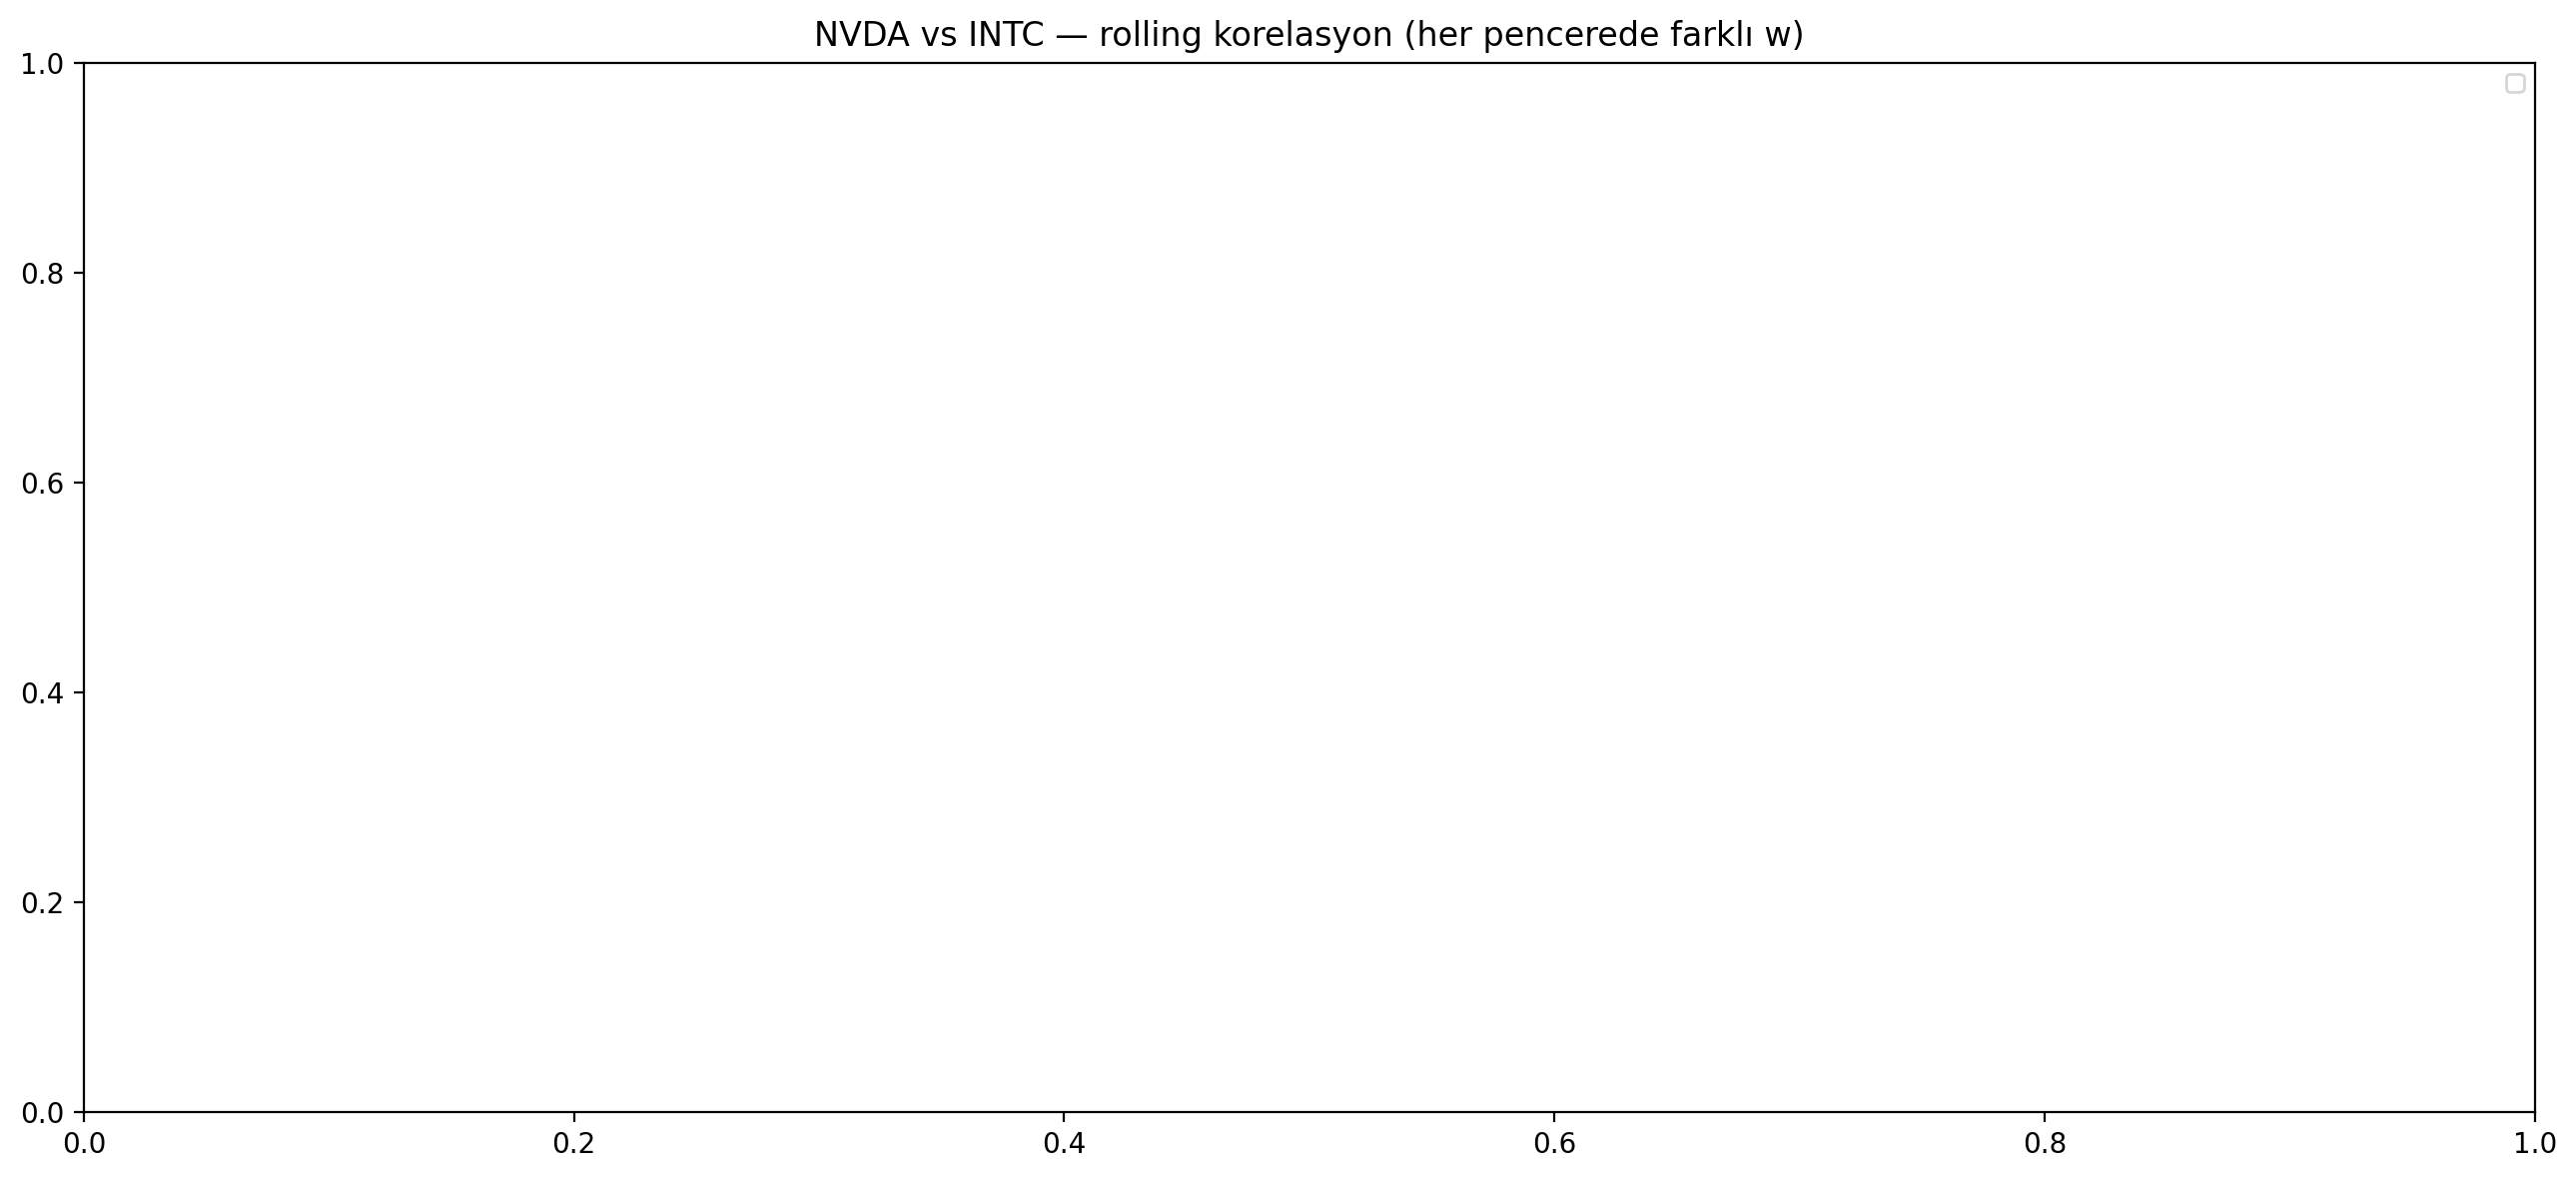

In [294]:
if "NVDA" in ret_w.columns and "INTC" in ret_w.columns:
    plt.figure(figsize=(13, 6), dpi=200)
    ax = plt.gca()
    for k, meta in corr_bundles.items():
        sub = slice_returns_calendar_tail(ret_w, meta["months"])
        if len(sub) < 15:
            continue
        w = min(60, max(10, len(sub) // 3))
        if len(sub) < w + 2:
            continue
        r = sub["NVDA"].rolling(w).corr(sub["INTC"]).dropna()
        ax.plot(r.index, r.values, lw=1.2, label=CORR_WINDOW_TITLE_TR.get(k, k))
    ax.set_title("NVDA vs INTC — rolling korelasyon (her pencerede farklı w)")
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
corr_density = []
for k in ("1m", "1y"):
    meta = corr_bundles.get(k)
    if not meta or meta["corr"].empty:
        continue
    c = meta["corr"].values.copy()
    np.fill_diagonal(c, np.nan)
    corr_density.append(
        {
            "pencere": CORR_WINDOW_TITLE_TR.get(k, k),
            "mean_abs_corr": float(np.nanmean(np.abs(c))),
        }
    )
tab_corr_cmp = pd.DataFrame(corr_density)
display(tab_corr_cmp)

In [ ]:
if len(tab_corr_cmp) >= 2:
    tab_corr_cmp.set_index("pencere")["mean_abs_corr"].plot.bar(
        figsize=(8, 4), title="Ortalama |ρ| (köşegen hariç)"
    )
    plt.tight_layout()
    plt.show()
_win_best = (
    tab_corr_cmp.loc[tab_corr_cmp["mean_abs_corr"].idxmax(), "pencere"]
    if len(tab_corr_cmp)
    else "—"
)
_win_best

In [ ]:
META_COLS = [
    "ticker",
    "sector",
    "event_date",
    "entry_date",
    "feature_date",
    "eps_estimate",
    "eps_reported",
]

def feature_columns(df: pd.DataFrame) -> List[str]:
    skip = set(META_COLS) | set(target_columns())
    num = []
    for c in df.columns:
        if c in skip:
            continue
        if df[c].dtype == object:
            continue
        num.append(c)
    return num

In [ ]:
feats = feature_columns(events)
print("Özellik sayısı:", len(feats))

for tcol in target_columns():
    plt.figure(figsize=(7, 4.5), dpi=200)
    events[tcol].dropna().hist(bins=40)
    plt.title(f"Hedef {tcol}")
    plt.tight_layout()
    plt.show()

tgt_stats = []
for tcol in target_columns():
    s = events[tcol].dropna()
    if s.empty:
        continue
    tgt_stats.append(
        {
            "hedef": tcol,
            "std": float(s.std()),
            "skew": float(s.skew()),
        }
    )
tab_tgt = pd.DataFrame(tgt_stats)
display(tab_tgt)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def numeric_pipeline(model) -> Pipeline:
    return Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", model),
        ]
    )

def prepare_xy_ts(
    df: pd.DataFrame,
    target: str,
    feature_cols: List[str],
    date_col: str = "entry_date",
    categorical: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    categorical = categorical or []
    work = df
    if date_col in df.columns:
        work = df.sort_values(date_col)
    use_cols = [c for c in feature_cols if c in work.columns]
    X = work[use_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    y = work[target].values.astype(float)
    mask = np.isfinite(y)
    X = X.loc[mask].reset_index(drop=True)
    y = y[mask]
    return X, y, use_cols

def prepare_xy(
    df: pd.DataFrame,
    target: str,
    feature_cols: List[str],
    categorical: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    return prepare_xy_ts(df, target, feature_cols, date_col="entry_date", categorical=categorical)


In [ ]:
from sklearn.model_selection import (
    BaseCrossValidator
)
from typing import Iterable
def time_series_cv_splits(
    n_samples: int,
    n_splits: int = 5,
    gap: int = 0,
    offset: int = 0,
) -> Iterable[Tuple[np.ndarray, np.ndarray]]:
    """
    Block expanding-window splits (article-style).
    Train = rows [0 : test_start - gap); test = [test_start : test_end).
  Skips folds with empty train or test_start beyond data.
    """
    if n_samples < 2 or n_splits < 1:
        return
    offset = max(0, int(offset))
    gap = max(0, int(gap))
    denom = max(1, n_splits)
    fold_size = max(1, (n_samples - offset) // denom)
    for i in range(n_splits):
        test_start = offset + i * fold_size + gap
        if test_start >= n_samples:
            continue
        test_end = test_start + fold_size if i < n_splits - 1 else n_samples
        if test_end <= test_start:
            continue
        train_end = max(offset, test_start - gap)
        if train_end < 1:
            continue
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        if len(train_idx) < 1 or len(test_idx) < 1:
            continue
        yield train_idx, test_idx

class TimeSeriesBlockCV(BaseCrossValidator):
    """Sklearn-compatible block time-series CV with gap and offset."""

    def __init__(self, n_splits: int = 5, gap: int = 0, offset: int = 0):
        self.n_splits = n_splits
        self.gap = gap
        self.offset = offset

    def get_n_splits(self, X=None, y=None, groups=None) -> int:
        n = len(X) if X is not None else 0
        return len(list(time_series_cv_splits(n, self.n_splits, self.gap, self.offset)))

    def split(self, X, y=None, groups=None):
        n = len(X)
        for train_idx, test_idx in time_series_cv_splits(
            n, self.n_splits, self.gap, self.offset
        ):
            yield train_idx, test_idx

def time_series_cv(
    n_splits: int = 5, gap: int = 0, offset: int = 0
) -> TimeSeriesBlockCV:
    return TimeSeriesBlockCV(n_splits=n_splits, gap=gap, offset=offset)

def cv_fold_sizes(cv: TimeSeriesBlockCV, n_samples: int) -> pd.DataFrame:
    rows = []
    for i, (tr, te) in enumerate(
        time_series_cv_splits(n_samples, cv.n_splits, cv.gap, cv.offset)
    ):
        rows.append(
            {
                "fold": i + 1,
                "n_train": len(tr),
                "n_test": len(te),
                "train_end": int(tr[-1]) if len(tr) else -1,
                "test_start": int(te[0]) if len(te) else -1,
            }
        )
    return pd.DataFrame(rows)

In [ ]:
def _focus_pred_axis(ax2, y_pred: np.ndarray) -> None:
    """Sağ ekseni yalnızca tahmin aralığına zoomla; küçük değerler okunaklı olsun."""
    from matplotlib.ticker import FormatStrFormatter, MaxNLocator

    p = np.asarray(y_pred, dtype=float)
    m = np.isfinite(p)
    if not m.any():
        return
    lo, hi = float(np.min(p[m])), float(np.max(p[m]))
    if lo == hi:
        pad = max(5e-4, abs(lo) * 0.35 + 1e-4)
        lo, hi = lo - pad, hi + pad
    else:
        pad = (hi - lo) * 0.18 + 1e-6
        lo, hi = lo - pad, hi + pad
    ax2.set_ylim(lo, hi)
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=7, min_n_ticks=4))
    span = hi - lo
    if span < 0.02:
        ax2.yaxis.set_major_formatter(FormatStrFormatter("%.5f"))
    elif span < 0.08:
        ax2.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    else:
        ax2.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
    ax2.grid(True, axis="y", linestyle=":", alpha=0.45, color="crimson")

def plot_time_series_cv_fold(
    ax,
    x: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    y_pred: Optional[np.ndarray] = None,
    title: str = "",
    *,
    twin_pred: bool = True,
) -> None:
    """Sol eksen: gerçek getiri; sağ eksen (isteğe bağlı): test tahminleri (ayrı ölçek, zoom)."""
    ax.axhline(0, color="k", lw=0.6, alpha=0.35)
    ax.plot(x, y, color="grey", alpha=0.35, label="Tüm veri")
    ax.scatter(x[train_idx], y[train_idx], color="blue", label="Eğitim", s=28, linewidths=0)
    ax.scatter(x[test_idx], y[test_idx], color="green", label="Test (gerçek)", s=34, linewidths=0)
    ax.set_ylabel("Gerçek getiri")
    handles, labels = ax.get_legend_handles_labels()

    if y_pred is not None:
        y_pred = np.asarray(y_pred, dtype=float)
        if twin_pred:
            ax2 = ax.twinx()
            xt = x[test_idx]
            ax2.plot(
                xt,
                y_pred,
                color="crimson",
                linestyle="-",
                linewidth=2.5,
                alpha=0.85,
                zorder=3,
            )
            ax2.scatter(
                xt,
                y_pred,
                color="red",
                edgecolors="darkred",
                linewidths=0.8,
                s=72,
                zorder=4,
                label="Tahmin (test)",
            )
            _focus_pred_axis(ax2, y_pred)
            ax2.set_ylabel("Tahmin (zoom)", color="crimson", fontsize=11)
            ax2.tick_params(axis="y", labelcolor="crimson", labelsize=10, width=1.1)
            h2, l2 = ax2.get_legend_handles_labels()
            handles, labels = handles + h2, labels + l2
        else:
            ax.plot(
                x[test_idx],
                y_pred,
                color="red",
                linestyle="--",
                linewidth=2.0,
                label="Tahmin (test)",
            )
            handles, labels = ax.get_legend_handles_labels()

    ax.set_title(title)
    if handles:
        ax.legend(handles, labels, loc="best", fontsize=8)

from sklearn.base import clone

def plot_all_cv_folds(
    X: pd.DataFrame,
    y: np.ndarray,
    model,
    cv: TimeSeriesBlockCV,
    *,
    x_series: Optional[np.ndarray] = None,
    figsize: Tuple[int, int] = (16, 11),
    dpi: int = 200,
) -> None:
    """One subplot per fold."""
    n = len(y)
    splits = list(time_series_cv_splits(n, cv.n_splits, cv.gap, cv.offset))
    if not splits:
        print("CV fold yok (yetersiz örnek).")
        return
    if x_series is None:
        x_series = np.arange(n, dtype=float)
    else:
        x_series = np.asarray(x_series, dtype=float)
    fig, axes = plt.subplots(
        len(splits),
        1,
        figsize=(figsize[0], max(3.4, 3.1 * len(splits))),
        dpi=dpi,
    )
    if len(splits) == 1:
        axes = [axes]
    est = clone(model)
    for i, (tr, te) in enumerate(splits):
        ax = axes[i]
        Xi = X.iloc[tr] if hasattr(X, "iloc") else X[tr]
        Xe = X.iloc[te] if hasattr(X, "iloc") else X[te]
        est.fit(Xi, y[tr])
        pred = est.predict(Xe)
        plot_time_series_cv_fold(
            ax,
            x_series,
            y,
            tr,
            te,
            y_pred=pred,
            title=f"Fold {i + 1} (gap={cv.gap}, offset={cv.offset})",
        )
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.linear_model import Ridge

_cv_demo_tgt = [c for c in target_columns() if c in events.columns][0]
X_cv, y_cv, _ = prepare_xy(events, _cv_demo_tgt, feats)
x_cv = np.arange(len(y_cv))
pipe_cv = numeric_pipeline(Ridge(alpha=1.0))


In [ ]:
cv_base = time_series_cv(5, gap=0, offset=0)
display(cv_fold_sizes(cv_base, len(y_cv)))
plot_all_cv_folds(X_cv, y_cv, pipe_cv, cv_base, x_series=x_cv)

In [ ]:
cv_gap = time_series_cv(5, gap=1, offset=0)
display(cv_fold_sizes(cv_gap, len(y_cv)))
plot_all_cv_folds(X_cv, y_cv, pipe_cv, cv_gap, x_series=x_cv)


In [ ]:
from typing import Sequence, Union
from sklearn.model_selection import (
    cross_val_score,
)

LabelSpec = Union[
    Tuple[str, Any],
    Tuple[str, Any, pd.DataFrame],
]

SCORING_NEG_RMSE = "neg_root_mean_squared_error"

def cv_eval(
    model,
    X: pd.DataFrame,
    y: np.ndarray,
    cv: Union[TimeSeriesBlockCV, Any],
    n_jobs: int = 1,
) -> Dict[str, float]:
    """n_jobs=1 by default: nested parallel CV is fragile; inf-cleaned X still safer serial."""
    scores = cross_val_score(
        model, X, y, cv=cv, scoring=SCORING_NEG_RMSE, n_jobs=n_jobs
    )
    scores = np.asarray(scores, dtype=float)
    if not np.isfinite(scores).all():
        scores = cross_val_score(
            model, X, y, cv=cv, scoring=SCORING_NEG_RMSE, n_jobs=1
        )
        scores = np.asarray(scores, dtype=float)
    rmse = -scores
    if not np.isfinite(rmse).any():
        return {"cv_rmse_mean": float("nan"), "cv_rmse_std": float("nan")}
    return {
        "cv_rmse_mean": float(np.nanmean(rmse)),
        "cv_rmse_std": float(np.nanstd(rmse)),
    }


def teach_cv_compare(
    label_specs: Sequence[LabelSpec],
    X: pd.DataFrame,
    y: np.ndarray,
    cv: TimeSeriesBlockCV,
    *,
    plot: bool = False,
    x_series: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    rows = []
    sizes = cv_fold_sizes(cv, len(y))
    n_train_min = int(sizes["n_train"].min()) if not sizes.empty else 0
    n_test_min = int(sizes["n_test"].min()) if not sizes.empty else 0
    first_est = None
    first_X = None
    for spec in label_specs:
        name = spec[0]
        est = spec[1]
        Xm = spec[2] if len(spec) > 2 else X
        if first_est is None:
            first_est, first_X = est, Xm
        out = cv_eval(est, Xm, y, cv)
        rows.append(
            {
                "yöntem": name,
                "cv_rmse_mean": out["cv_rmse_mean"],
                "cv_rmse_std": out["cv_rmse_std"],
                "n_train_min": n_train_min,
                "n_test_min": n_test_min,
            }
        )
    tab = pd.DataFrame(rows)
    if plot and first_est is not None and first_X is not None:
        plot_all_cv_folds(first_X, y, first_est, cv, x_series=x_series)
    return tab

In [ ]:
cv_gap = time_series_cv(5, gap=1, offset=0)
tab_gap0 = teach_cv_compare([("gap=0", pipe_cv)], X_cv, y_cv, cv_base)
tab_gap1 = teach_cv_compare([("gap=1", pipe_cv)], X_cv, y_cv, cv_gap)
tab_gap = pd.concat([tab_gap0, tab_gap1], ignore_index=True)
display(tab_gap)

In [ ]:
lag_cols = [c for c in feats if "lag" in c or "prior_post" in c or "surprise_lag" in c]
feats_nolag = [c for c in feats if c not in lag_cols]
X_nolag, y_nl, _ = prepare_xy(events, _cv_demo_tgt, feats_nolag)
X_lag, y_lg, _ = prepare_xy(events, _cv_demo_tgt, feats)

tab_nolag = teach_cv_compare(
    [
        ("lagsiz", pipe_cv),
    ],
    X_nolag,
    y_nl,
    cv_base,
)
tab_lag = teach_cv_compare(
	[
		("gecikmeli", pipe_cv)
	],
	X_lag,
	y_lg,
	cv_base,
)
display(pd.concat([tab_nolag, tab_lag], ignore_index=True))

In [ ]:
off = max(10, len(y_cv) // 10)
cv_off = time_series_cv(5, gap=0, offset=off)
display(cv_fold_sizes(cv_off, len(y_cv)))
plot_all_cv_folds(X_cv, y_cv, pipe_cv, cv_off, x_series=x_cv)

In [ ]:
cv = time_series_cv(5, gap=0, offset=0)
_g0 = tab_gap0["cv_rmse_mean"].iloc[0] if len(tab_gap0) else np.nan
_g1 = tab_gap1["cv_rmse_mean"].iloc[0] if len(tab_gap1) else np.nan
_use_gap = 1 if np.isfinite(_g0) and np.isfinite(_g1) and _g1 <= _g0 else 0
if _use_gap:
    cv = time_series_cv(5, gap=1, offset=0)
else:
	cv = time_series_cv(5, gap=0, offset=0)

In [ ]:
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso
from sklearn.feature_selection import RFE, SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV

def linear_baseline_cv(X, y, cv) -> Dict[str, Any]:
    pipe = numeric_pipeline(LinearRegression())
    return {"model": pipe, **cv_eval(pipe, X, y, cv)}

def drop_high_corr_columns(X: pd.DataFrame, threshold: float = 0.95) -> pd.DataFrame:
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return X.drop(columns=to_drop, errors="ignore")

def correlation_prune_cv(X, y, cv, threshold=0.95) -> Dict[str, Any]:
    Xp = drop_high_corr_columns(X, threshold=threshold)
    pipe = numeric_pipeline(LinearRegression())
    return {"model": pipe, "X": Xp, **cv_eval(pipe, Xp, y, cv)}

def select_k_best_cv(X, y, cv, k=25) -> Dict[str, Any]:
    pipe = Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("kb", SelectKBest(score_func=f_regression, k=min(k, X.shape[1]))),
            ("sc", StandardScaler()),
            ("m", LinearRegression()),
        ]
    )
    return {"model": pipe, **cv_eval(pipe, X, y, cv)}

def rfe_cv(X, y, cv, n_features=25) -> Dict[str, Any]:
    n_feat = min(n_features, X.shape[1] - 1, max(1, X.shape[1] // 2))
    base = Ridge(alpha=1.0)
    rfe = RFE(estimator=base, n_features_to_select=n_feat, step=1)
    pipe = Pipeline(
        [("imp", SimpleImputer(strategy="median")), ("rfe", rfe), ("sc", StandardScaler()), ("m", LinearRegression())]
    )
    return {"model": pipe, **cv_eval(pipe, X, y, cv)}

def materialize_fs_matrix(
    fs_name: str,
    X: pd.DataFrame,
    y: np.ndarray,
    bundles: Dict[str, Any],
) -> pd.DataFrame:
    """CV sırasında üretilen FS bundle'larından tam veri üzerinde özellik alt matrisi (tahmin için)."""
    if fs_name == "baseline":
        return X.copy()
    if fs_name == "corr_prune":
        return bundles["corr_prune"]["X"].copy()
    if fs_name not in bundles:
        return X.copy()
    pipe = bundles[fs_name]["model"]
    pipe.fit(X, y)
    if fs_name == "kbest":
        return X.loc[:, pipe.named_steps["kb"].get_support()].copy()
    if fs_name == "rfe":
        return X.loc[:, pipe.named_steps["rfe"].support_].copy()
    return X.copy()

def grid_regularized(
    X,
    y,
    cv,
    kind: str = "ridge",
    alphas: Optional[List[float]] = None,
) -> Dict[str, Any]:
    alphas = alphas or [1e-3, 1e-2, 0.1, 1, 10, 100]
    if kind == "ridge":
        est = Ridge()
        param = {"m__alpha": alphas}
    elif kind == "lasso":
        est = Lasso(max_iter=5000)
        param = {"m__alpha": alphas}
    else:
        est = ElasticNet(max_iter=8000, l1_ratio=0.5)
        param = {"m__alpha": alphas}
    pipe = numeric_pipeline(est)
    gs = GridSearchCV(
        pipe,
        param,
        cv=cv,
        scoring=SCORING_NEG_RMSE,
        n_jobs=1,
        refit=True,
    )
    gs.fit(X, y)
    return {"model": gs.best_estimator_, "grid": gs, **cv_eval(gs.best_estimator_, X, y, cv)}



In [ ]:
per_target = {}

for tgt in target_columns():
    X_all, y_all, _ = prepare_xy(events, tgt, feats)
    bundles = {}
    bundles["baseline"] = linear_baseline_cv(X_all, y_all, cv)
    bundles["corr_prune"] = correlation_prune_cv(X_all, y_all, cv)
    bundles["kbest"] = select_k_best_cv(X_all, y_all, cv)
    bundles["rfe"] = rfe_cv(X_all, y_all, cv)
    tab_fs = (
        pd.DataFrame(
            {
                "yöntem": list(bundles.keys()),
                "cv_rmse_mean": [bundles[k]["cv_rmse_mean"] for k in bundles],
                "cv_rmse_std": [bundles[k]["cv_rmse_std"] for k in bundles],
            }
        )
        .set_index("yöntem")
    )
    s = tab_fs["cv_rmse_mean"].replace([np.inf, -np.inf], np.nan)
    if s.dropna().empty:
        continue
    best_fs = str(s.idxmin())
    best_X = materialize_fs_matrix(best_fs, X_all, y_all, bundles)
    res_ridge = grid_regularized(best_X, y_all, cv, kind="ridge")
    res_lasso = grid_regularized(best_X, y_all, cv, kind="lasso")
    res_enet = grid_regularized(best_X, y_all, cv, kind="elastic")
    lin_rmse = {
        "Ridge": float(res_ridge["cv_rmse_mean"]),
        "Lasso": float(res_lasso["cv_rmse_mean"]),
        "ElasticNet": float(res_enet["cv_rmse_mean"]),
    }
    best_reg = min(lin_rmse, key=lin_rmse.get)
    cv_best_lin = min(lin_rmse.values())
    per_target[tgt] = {
        "X": best_X,
        "y": y_all,
        "best_fs": best_fs,
        "best_reg": best_reg,
        "tab_fs": tab_fs.reset_index(),
        "bundles": bundles,
        "res_ridge": res_ridge,
        "res_lasso": res_lasso,
        "res_enet": res_enet,
        "cv_best_lin": cv_best_lin,
    }

tab_fs_all = pd.concat(
    [per_target[t]["tab_fs"].assign(hedef=t) for t in per_target],
    ignore_index=True,
)
display(tab_fs_all)

In [ ]:
summary_linear = pd.DataFrame(
    [
        {
            "hedef": t,
            "best_fs": per_target[t]["best_fs"],
            "best_reg": per_target[t]["best_reg"],
            "cv_rmse_linear": per_target[t]["cv_best_lin"],
        }
        for t in per_target
    ]
)
display(summary_linear)

In [ ]:
def pick_viz_target(
    per_target: Dict[str, Any],
    fallback: Optional[str] = None,
    metric_key: str = "cv_best_lin",
) -> Optional[str]:
    if not per_target:
        return fallback
    scored = []
    for t, d in per_target.items():
        v = d.get(metric_key)
        if v is not None and np.isfinite(v):
            scored.append((t, float(v)))
    if scored:
        return min(scored, key=lambda x: x[1])[0]
    return fallback or next(iter(per_target.keys()), None)

REG_KEY = {"Ridge": "res_ridge", "Lasso": "res_lasso", "ElasticNet": "res_enet"}
viz_target = pick_viz_target(per_target, fallback=next(iter(per_target), None))
print("Görselleştirme (viz_target):", viz_target)

In [ ]:
best_X = per_target[viz_target]["X"]
y_all = per_target[viz_target]["y"]
res_ridge = per_target[viz_target]["res_ridge"]
res_lasso = per_target[viz_target]["res_lasso"]
res_enet = per_target[viz_target]["res_enet"]
tab_linear_fs = per_target[viz_target]["tab_fs"]

reg_compare = pd.DataFrame(
    {
        "model": ["Ridge", "Lasso", "ElasticNet"],
        "cv_rmse_mean": [
            res_ridge["cv_rmse_mean"],
            res_lasso["cv_rmse_mean"],
            res_enet["cv_rmse_mean"],
        ],
    }
)
display(reg_compare)


In [ ]:
ridge_lasso_enet_kiyaslama = pd.DataFrame(
    [
        {
            "hedef": t,
            "cv_ridge": per_target[t]["res_ridge"]["cv_rmse_mean"],
            "cv_lasso": per_target[t]["res_lasso"]["cv_rmse_mean"],
            "cv_enet": per_target[t]["res_enet"]["cv_rmse_mean"],
            "std_ridge": per_target[t]["res_ridge"]["cv_rmse_std"],
            "std_lasso": per_target[t]["res_lasso"]["cv_rmse_std"],
            "std_enet": per_target[t]["res_enet"]["cv_rmse_std"],
        }
        for t in per_target
    ]
)
ridge_lasso_enet_kiyaslama["fark_lasso_minus_ridge"] = (
    ridge_lasso_enet_kiyaslama["cv_lasso"] - ridge_lasso_enet_kiyaslama["cv_ridge"]
)
ridge_lasso_enet_kiyaslama["kazanan"] = np.where(
    ridge_lasso_enet_kiyaslama["cv_ridge"] <= ridge_lasso_enet_kiyaslama["cv_lasso"],
    "Ridge",
    "Lasso",
)
display(ridge_lasso_enet_kiyaslama.sort_values("hedef"))
print(
    "Özet: Ridge kazanan hedef sayısı:",
    int((ridge_lasso_enet_kiyaslama["kazanan"] == "Ridge").sum()),
    "| Lasso:",
    int((ridge_lasso_enet_kiyaslama["kazanan"] == "Lasso").sum()),
    "| ElasticNet:",
    int((ridge_lasso_enet_kiyaslama["kazanan"] == "ElasticNet").sum()),
)

In [ ]:
plt.figure(figsize=(12, 6), dpi=200)
x = np.arange(len(ridge_lasso_enet_kiyaslama))
w = 0.35
rl_df = ridge_lasso_enet_kiyaslama.sort_values("hedef").reset_index(drop=True)
plt.bar(x - w / 2, rl_df["cv_ridge"], width=w, label="Ridge")
plt.bar(x + w / 2, rl_df["cv_lasso"], width=w, label="Lasso")
plt.bar(x, rl_df["cv_enet"], width=w, label="ElasticNet")
plt.xticks(x, rl_df["hedef"], rotation=45, ha="right")
plt.ylabel("CV RMSE")
plt.title("Ridge vs Lasso vs ElasticNet — tüm hedefler (her hedefin seçilmiş FS matrisi)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
tab_viz_fs = per_target[viz_target]["tab_fs"]
tab_viz_fs.set_index("yöntem")["cv_rmse_mean"].plot.bar(
    figsize=(10, 4), title=f"FS karşılaştırma — {viz_target}"
)
plt.ylabel("CV RMSE")
plt.tight_layout()
plt.show()
top2 = tab_viz_fs.nsmallest(2, "cv_rmse_mean")["yöntem"].tolist()
for fs_name in top2[:2]:
    Xm = materialize_fs_matrix(
        fs_name, per_target[viz_target]["X"], per_target[viz_target]["y"], per_target[viz_target]["bundles"]
    )
    plot_all_cv_folds(
        Xm,
        per_target[viz_target]["y"],
        per_target[viz_target]["bundles"][fs_name]["model"],
        cv,
        x_series=np.arange(len(per_target[viz_target]["y"])),
    )

In [ ]:
_win_reg = per_target[viz_target]["best_reg"]
plot_all_cv_folds(
    best_X,
    y_all,
    per_target[viz_target][REG_KEY[_win_reg]]["model"],
    cv,
    x_series=np.arange(len(y_all)),
)

In [ ]:
### TODO: katsayı yollarını ekrana çizdir

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

def classification_pipeline(est) -> Pipeline:
    return Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", est),
        ]
    )

def discriminant_bundle() -> Dict[str, Pipeline]:
    return {
        "LDA": classification_pipeline(LinearDiscriminantAnalysis()),
        "QDA": classification_pipeline(QuadraticDiscriminantAnalysis(reg_param=0.1)),
        "NaiveBayes": classification_pipeline(GaussianNB()),
    }

CLASSIFICATION_BEAT_EXCLUDE = [
    "eps_beat",
    "eps_surprise_pct",
    "eps_estimate",
    "eps_reported",
]

def classification_feature_columns(
    df: pd.DataFrame,
    label_kind: str = "beat",
    horizon: Optional[str] = None,
) -> List[str]:
    """Features for classification; excludes label leakage columns."""
    cols = feature_columns(df)
    if label_kind == "beat":
        excl = set(CLASSIFICATION_BEAT_EXCLUDE)
        return [c for c in cols if c not in excl]
    return cols

def prepare_xy_class(
    df: pd.DataFrame,
    label_col: str,
    feature_cols: List[str],
    date_col: str = "entry_date",
) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    """Chronological rows with binary labels in {0, 1}."""
    work = df.sort_values(date_col) if date_col in df.columns else df
    use_cols = [c for c in feature_cols if c in work.columns and c != label_col]
    X = work[use_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    y_raw = work[label_col].values.astype(float)
    mask = np.isfinite(y_raw) & np.isin(y_raw, [0.0, 1.0])
    X = X.loc[mask].reset_index(drop=True)
    y = y_raw[mask].astype(int)
    return X, y, use_cols

In [ ]:
clf_models = discriminant_bundle()
feats_beat = classification_feature_columns(events, "beat")
X_beat, y_beat, _ = prepare_xy_class(events, "eps_beat", feats_beat)

tab_balance = (
    pd.Series(y_beat, name="eps_beat")
    .value_counts()
    .rename_axis("sinif")
    .reset_index(name="adet")
)
tab_balance["oran"] = tab_balance["adet"] / tab_balance["adet"].sum()
display(tab_balance)
tab_balance.set_index("sinif")["adet"].plot.bar(
    figsize=(7, 4.5), title="eps_beat sınıf dengesi"
)
plt.ylabel("adet")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

def cv_eval_classification(
    model,
    X: pd.DataFrame,
    y: np.ndarray,
    cv: Union[TimeSeriesBlockCV, Any],
    scoring: str = "roc_auc",
) -> Dict[str, float]:
    """Time-series CV with ROC-AUC (fallback accuracy when AUC undefined)."""
    scores: List[float] = []
    Xv = X
    for tr, te in cv.split(Xv, y):
        y_tr, y_te = y[tr], y[te]
        if len(np.unique(y_tr)) < 2:
            continue
        est = clone(model)
        Xi_tr = Xv.iloc[tr] if hasattr(Xv, "iloc") else Xv[tr]
        Xi_te = Xv.iloc[te] if hasattr(Xv, "iloc") else Xv[te]
        try:
            est.fit(Xi_tr, y_tr)
        except Exception:
            continue
        try:
            if scoring == "roc_auc" and len(np.unique(y_te)) >= 2:
                proba = est.predict_proba(Xi_te)
                if proba.shape[1] < 2:
                    scores.append(float(accuracy_score(y_te, est.predict(Xi_te))))
                else:
                    scores.append(float(roc_auc_score(y_te, proba[:, 1])))
            else:
                scores.append(float(accuracy_score(y_te, est.predict(Xi_te))))
        except Exception:
            continue
    if not scores:
        return {"cv_score_mean": float("nan"), "cv_score_std": float("nan")}
    arr = np.asarray(scores, dtype=float)
    return {
        "cv_score_mean": float(np.nanmean(arr)),
        "cv_score_std": float(np.nanstd(arr)),
    }
def teach_cv_compare_classify(
    label_specs: Sequence[LabelSpec],
    X: pd.DataFrame,
    y: np.ndarray,
    cv: TimeSeriesBlockCV,
    *,
    scoring: str = "roc_auc",
    plot: bool = False,
    x_series: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    rows = []
    sizes = cv_fold_sizes(cv, len(y))
    n_train_min = int(sizes["n_train"].min()) if not sizes.empty else 0
    n_test_min = int(sizes["n_test"].min()) if not sizes.empty else 0
    first_est = None
    first_X = None
    for spec in label_specs:
        name = spec[0]
        est = spec[1]
        Xm = spec[2] if len(spec) > 2 else X
        if first_est is None:
            first_est, first_X = est, Xm
        out = cv_eval_classification(est, Xm, y, cv, scoring=scoring)
        rows.append(
            {
                "yöntem": name,
                "cv_score_mean": out["cv_score_mean"],
                "cv_score_std": out["cv_score_std"],
                "n_train_min": n_train_min,
                "n_test_min": n_test_min,
            }
        )
    tab = pd.DataFrame(rows)
    if plot and first_est is not None and first_X is not None:
        plot_all_cv_folds(first_X, y.astype(float), first_est, cv, x_series=x_series)
    return tab

In [ ]:
specs_beat = [(n, clf_models[n]) for n in clf_models]
tab_clf_beat = teach_cv_compare_classify(specs_beat, X_beat, y_beat, cv)
display(tab_clf_beat)
tab_clf_beat.set_index("yöntem")["cv_score_mean"].plot.bar(
    figsize=(8, 4.5), title="ROC-AUC (CV) — eps_beat"
)
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

In [ ]:

_beat_winner = str(tab_clf_beat.loc[tab_clf_beat["cv_score_mean"].idxmax(), "yöntem"])
_best_beat_pipe = clf_models[_beat_winner]
teach_cv_compare_classify(
    [(_beat_winner, _best_beat_pipe)],
    X_beat,
    y_beat,
    cv,
    plot=True,
    x_series=np.arange(len(y_beat)),
)
clf_beat_auc = float(tab_clf_beat["cv_score_mean"].max())
print(clf_beat_auc)

In [ ]:
def make_direction_label(events: pd.DataFrame, horizon_col: str) -> pd.Series:
    """Binary 1 if forward return > 0, NaN if return missing."""
    if horizon_col not in events.columns:
        return pd.Series(np.nan, index=events.index)
    r = events[horizon_col].astype(float)
    out = pd.Series(np.nan, index=events.index, dtype=float)
    m = np.isfinite(r.values)
    out.loc[m] = (r.loc[m] > 0).astype(float)
    return out

rows_dir = []
feats_dir = classification_feature_columns(events, "direction")
for h in target_columns():
    ev_h = events.copy()
    ev_h["_dir"] = make_direction_label(events, h)
    Xd, yd, _ = prepare_xy_class(ev_h, "_dir", feats_dir)
    if len(yd) < 30 or len(np.unique(yd)) < 2:
        continue
    tab_h = teach_cv_compare_classify(specs_beat, Xd, yd, cv)
    for _, r in tab_h.iterrows():
        rows_dir.append(
            {
                "hedef": h,
                "yöntem": r["yöntem"],
                "cv_score_mean": r["cv_score_mean"],
                "cv_score_std": r["cv_score_std"],
            }
        )
tab_clf_direction = pd.DataFrame(rows_dir)
display(tab_clf_direction)

In [ ]:
if not tab_clf_direction.empty:
    pv_auc = tab_clf_direction.pivot_table(
        index="hedef", columns="yöntem", values="cv_score_mean", aggfunc="first"
    )
    display(pv_auc.assign(best_clf=pv_auc.idxmax(axis=1)))
    viz_horizon = str(pv_auc.max(axis=1).idxmax())
    clf_dir_winner = str(pv_auc.loc[viz_horizon].idxmax())
    clf_dir_auc = float(pv_auc.loc[viz_horizon].max())
    pv_auc.max(axis=1).plot.bar(
        figsize=(11, 4.5), title="En iyi model ROC-AUC (horizon başına)"
    )
    plt.ylabel("max ROC-AUC")
    plt.tight_layout()
    plt.show()
    ev_v = events.copy()
    ev_v["_dir"] = make_direction_label(events, viz_horizon)
    Xv, yv, _ = prepare_xy_class(ev_v, "_dir", feats_dir)
    teach_cv_compare_classify(
        [(clf_dir_winner, clf_models[clf_dir_winner])],
        Xv,
        yv,
        cv,
        plot=True,
        x_series=np.arange(len(yv)),
    )
    print(f"Getiri yönü en ayırt edilebilir horizon: **{viz_horizon}**; model **{clf_dir_winner}** (AUC ≈ {clf_dir_auc:.3f}).")
else:
    viz_horizon = ""
    clf_dir_winner = ""
    clf_dir_auc = float("nan")
    print("Yeterli etiketli satır yok; yön sınıflandırması atlandı.")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

try:
    import xgboost as xgb
except ImportError:
    xgb = None
try:
    import lightgbm as lgb
except ImportError:
    lgb = None

def randomized_xgb(X, y, cv, n_iter=24, seed=42) -> Dict[str, Any]:
    if xgb is None:
        return {}
    reg = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        random_state=seed,
        tree_method="hist",
        n_jobs=-1,
        verbosity=0,
    )
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("m", reg)])
    space = {
        "m__max_depth": [3, 5, 7, 10],
        "m__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "m__subsample": [0.6, 0.8, 1.0],
        "m__colsample_bytree": [0.6, 0.8, 1.0],
        "m__reg_alpha": [0, 0.1, 1],
        "m__reg_lambda": [0, 0.1, 1],
        "m__min_child_weight": [1, 3],
    }
    rs = RandomizedSearchCV(
        pipe,
        space,
        n_iter=n_iter,
        cv=cv,
        scoring=SCORING_NEG_RMSE,
        random_state=seed,
        n_jobs=1,
        refit=True,
    )
    rs.fit(X, y)
    return {"model": rs.best_estimator_, "search": rs, **cv_eval(rs.best_estimator_, X, y, cv)}


def randomized_lgbm(X, y, cv, n_iter=24, seed=42) -> Dict[str, Any]:
    if lgb is None:
        return {}
    reg = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=300,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
        min_child_samples=1,
        min_data_in_leaf=1,
    )
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("m", reg)])
    space = {
        "m__max_depth": [3, 5, 7, 10, -1],
        "m__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "m__subsample": [0.6, 0.8, 1.0],
        "m__colsample_bytree": [0.6, 0.8, 1.0],
        "m__reg_alpha": [0, 0.1, 1],
        "m__reg_lambda": [0, 0.1, 1],
        "m__min_child_samples": [1, 5, 10],
    }
    rs = RandomizedSearchCV(
        pipe,
        space,
        n_iter=n_iter,
        cv=cv,
        scoring=SCORING_NEG_RMSE,
        random_state=seed,
        n_jobs=1,
        refit=True,
    )
    rs.fit(X, y)
    return {"model": rs.best_estimator_, "search": rs, **cv_eval(rs.best_estimator_, X, y, cv)}

In [ ]:
rows_gbm = []
for tgt in target_columns():
    if tgt not in per_target:
        continue
    Xb, yb = per_target[tgt]["X"], per_target[tgt]["y"]
    rx_t = randomized_xgb(Xb, yb, cv, n_iter=12)
    rl_t = randomized_lgbm(Xb, yb, cv, n_iter=12)
    per_target[tgt]["rx"] = rx_t
    per_target[tgt]["rl"] = rl_t
    xrm = (
        float(rx_t["cv_rmse_mean"])
        if rx_t and np.isfinite(rx_t.get("cv_rmse_mean", np.nan))
        else np.nan
    )
    lrm = (
        float(rl_t["cv_rmse_mean"])
        if rl_t and np.isfinite(rl_t.get("cv_rmse_mean", np.nan))
        else np.nan
    )
    if np.isfinite(xrm) and np.isfinite(lrm):
        winner = "XGB" if xrm <= lrm else "LGBM"
        gbest = min(xrm, lrm)
    elif np.isfinite(xrm):
        winner, gbest = "XGB", xrm
    elif np.isfinite(lrm):
        winner, gbest = "LGBM", lrm
    else:
        winner, gbest = "", np.nan
    per_target[tgt]["tree_winner"] = winner
    per_target[tgt]["cv_tree_best"] = gbest
    rows_gbm.append(
        {
            "hedef": tgt,
            "cv_xgb": xrm,
            "cv_lgbm": lrm,
            "tree_winner": winner,
            "cv_tree_best": gbest,
        }
    )
tab_gbm = pd.DataFrame(rows_gbm)
display(tab_gbm)

In [ ]:
rx = per_target[viz_target]["rx"]
rl = per_target[viz_target]["rl"]
display(
    pd.DataFrame(
        [
            {"model": "XGB", **{k: rx.get(k) for k in ["cv_rmse_mean", "cv_rmse_std"] if rx}},
            {"model": "LGBM", **{k: rl.get(k) for k in ["cv_rmse_mean", "cv_rmse_std"] if rl}},
        ]
    )
)

In [ ]:
if rx and rl:
    teach_cv_compare(
        [("XGB", rx["model"]), ("LGBM", rl["model"])],
        best_X,
        y_all,
        cv,
        plot=True,
        x_series=np.arange(len(y_all)),
    )
_xgb_w = int((tab_gbm["tree_winner"] == "XGB").sum())
_lgb_w = int((tab_gbm["tree_winner"] == "LGBM").sum())
_vt_lin = per_target[viz_target]["cv_best_lin"]
_vt_tree = per_target[viz_target].get("cv_tree_best", np.nan)
print(f"Ağaç kazananları: XGB {_xgb_w} hedef, LGBM {_lgb_w} hedef — horizon’a göre değişir.")
print(f"`{viz_target}`: linear {_vt_lin:.4f} vs en iyi ağaç {_vt_tree:.4f} RMSE — hangisi düşükse o veri için tercih.")

In [ ]:
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.inspection import permutation_importance

def _is_degenerate_gbm(est, Xt: np.ndarray, y: np.ndarray) -> bool:
    """True when the fitted booster ignores features (constant predictions or zero FI)."""
    pred = np.asarray(est.predict(Xt), dtype=float)
    y_std = float(np.std(y))
    if y_std > 1e-12 and float(np.std(pred)) < max(1e-10, 1e-4 * y_std):
        return True
    fi = getattr(est, "feature_importances_", None)
    if fi is not None and fi.size and float(np.max(fi)) == 0.0:
        return True
    return False

def _interpretable_gbm(est):
    """Moderate regularization so trees split for permutation / importance plots."""
    if xgb is not None and isinstance(est, xgb.XGBRegressor):
        return xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            min_child_weight=1,
            tree_method="hist",
            n_jobs=-1,
            verbosity=0,
        )
    if lgb is not None and isinstance(est, lgb.LGBMRegressor):
        return lgb.LGBMRegressor(
            objective="regression",
            n_estimators=300,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            min_child_samples=5,
            n_jobs=-1,
            verbosity=-1,
        )
    return clone(est)

def gbm_permutation_importance(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: np.ndarray,
    *,
    n_repeats: int = 10,
    random_state: int = 0,
    top_n: int = 15,
) -> Tuple[pd.Series, str]:
    """
    Permutation importance on imputed features (inner booster, not full Pipeline).

    If CV-tuned XGB/LGBM collapses to a constant predictor, refits a moderate
  model for interpretation only so importances are meaningful.
    """
    pipe = clone(pipeline)
    pipe.fit(X, y)
    Xt = pipe.named_steps["imp"].transform(X)
    cols = list(X.columns) if hasattr(X, "columns") else [f"f{i}" for i in range(Xt.shape[1])]
    note = ""
    if _is_degenerate_gbm(pipe.named_steps["m"], Xt, y):
        reg = _interpretable_gbm(pipe.named_steps["m"])
        reg.fit(Xt, y)
        note = (
            "CV modeli özellikleri kullanmıyordu (sabit tahmin); "
            "permutation importance için yorumlanabilir parametrelerle yeniden eğitildi."
        )
    else:
        reg = pipe.named_steps["m"]
    scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
    pi = permutation_importance(
        reg,
        Xt,
        y,
        scoring=scorer,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=1,
    )
    imp = pd.Series(pi.importances_mean, index=cols).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    imp = imp.sort_values(ascending=False).head(top_n)
    return imp, note

In [ ]:
if rx:
    imp, pi_note = gbm_permutation_importance(
        rx["model"], best_X, y_all, n_repeats=10, random_state=0, top_n=15
    )
    if pi_note:
        print(pi_note)
    display(imp.to_frame("perm_importance"))
    if imp.max() > 0:
        imp.sort_values().plot.barh(
            figsize=(10, 7),
            title=f"Permutation importance (XGB) — {viz_target}",
        )
        plt.tight_layout()
        plt.show()
    else:
        print("Permutation importance hâlâ sıfır; özellikler hedefle zayıf ilişkili olabilir.")

In [ ]:
try:
    import shap

    if rx:
        est = rx["model"].named_steps["m"]
        Xs = best_X.sample(min(400, len(best_X)), random_state=0)
        explainer = shap.TreeExplainer(est)
        sv = explainer.shap_values(Xs)
        shap.summary_plot(
            sv, Xs, show=True, max_display=12, plot_size=(16.0, 9.0)
        )
except Exception as e:
    print("SHAP atlandı:", e)

Bu adımın amacı "En mükemmel tahmin yapan indikatörü veya en iyi regülasyon katsayısını bulalım" değildir.

Eğer 4 farklı havuzlama modu için ayrı ayrı hem Lasso, hem Ridge, hem ElasticNet çalıştırıp, her biri için devasa parametre gridleri aransaydı, denetlemek istediğin asıl hipotez (havuzlama mantığı) parametre optimizasyonunun gürültüsü arasında kaybolurdu.

Neden Lasso veya ElasticNet Değil de Sadece Ridge?
"Neden tek bir model seçildi?" sorusunun cevabı Ridge iken, "Neden Ridge?" sorusunun cevabı finansal verinin doğasında saklıdır:

Çoklu Doğrusallık (Multicollinearity): Teknik analiz fonksiyonunda gördüğümüz gibi veri setinde birbirine çok benzeyen (yüksek korelasyonlu) değişkenler var (ret_1d, ret_2d, ret_5d veya mkt_ret_1d, sector_ret_1d).

Katsayıları Sıfırlamama Arzusu: Lasso, birbirine benzeyen değişkenlerden birini seçip diğerlerini tamamen sıfır (0) yapar. Ancak bu adımda özellikle multi_ticker_dummies ve sector_ret etkilerini test ediyorsun. Lasso kullanılsaydı, model bazı ticker dummy değişkenlerini veya sektör getirisini tamamen kapatabilirdi (katsayısını sıfır yaparak). O zaman da "Sektör getirisi eklemek modeli iyileştirdi mi?" sorusuna adil bir cevap alamazdın.

Ridge'in Çözümü: Ridge (L2 regülasyonu) katsayıları sıfır yapmaz, birbirine benzeyen değişkenlerin katsayılarını birlikte küçülterek (shrinkage) modele dahil eder. Böylece dummy değişkenlerin ve sektörün etkisini skor tablosunda ham bir şekilde görebilirsin.

Lasso, birbirine benzeyen değişkenlerden birini seçip diğerlerini tamamen sıfır (0) yapar. Ancak bu adımda özellikle multi_ticker_dummies ve sector_ret etkilerini test ediyorsun. Lasso kullanılsaydı, model bazı ticker dummy değişkenlerini veya sektör getirisini tamamen kapatabilirdi (katsayısını sıfır yaparak). O zaman da "Sektör getirisi eklemek modeli iyileştirdi mi?" sorusuna adil bir cevap alamazdın.

Daha önce en iyi modeli arıyordun (Model Selection). Şimdi ise en doğru veri besleme stratejisini arıyorsun (Data Architecture Selection).

In [ ]:
rows_m_all = []
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def add_ticker_dummies(df: pd.DataFrame, X: pd.DataFrame) -> pd.DataFrame:
    d = pd.get_dummies(df["ticker"], prefix="tk")
    return pd.concat([X.reset_index(drop=True), d.reset_index(drop=True)], axis=1)

def add_sector_peer_returns(
    events: pd.DataFrame, X: pd.DataFrame, sector_ret_col: str = "sector_ret_1d"
) -> pd.DataFrame:
    """Append sector basket return column from events (same as ETF-era helper, new name)."""
    if sector_ret_col in events.columns:
        extra = events[[sector_ret_col]].copy()
        extra.columns = ["sector_feat_ret"]
        return pd.concat([X.reset_index(drop=True), extra.reset_index(drop=True)], axis=1)
    return X

def ridge_cv_rmse(Xm, ym, splits=5):
    cvm = time_series_cv(splits)
    if len(Xm) < splits + 5:
        return np.nan, np.nan
    pipe = Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", RidgeCV(alphas=np.logspace(-3, 2, 12))),
        ]
    )
    out = cv_eval(pipe, Xm, ym, cvm)
    return out["cv_rmse_mean"], out["cv_rmse_std"]

for tgt in target_columns():
    if tgt not in per_target:
        continue
    ev = events.dropna(subset=[tgt], how="any").sort_values("entry_date")
    if len(ev) < 30:
        continue
    Xb, yb, _ = prepare_xy(ev, tgt, feats)
    Xbp = drop_high_corr_columns(Xb, 0.95)
    m0, s0 = ridge_cv_rmse(Xbp, yb)
    rows_m_all.append(
        {"hedef": tgt, "mode": "pooled_by_entry_date", "cv_rmse_mean": m0, "cv_rmse_std": s0}
    )
    Xm2 = add_ticker_dummies(ev, Xbp)
    m2, s2 = ridge_cv_rmse(Xm2, yb)
    rows_m_all.append(
        {"hedef": tgt, "mode": "multi_ticker_dummies", "cv_rmse_mean": m2, "cv_rmse_std": s2}
    )
    Xm3 = add_sector_peer_returns(ev, Xm2)
    m3, s3 = ridge_cv_rmse(Xm3, yb)
    rows_m_all.append(
        {
            "hedef": tgt,
            "mode": "multi_dummies_sector_ret",
            "cv_rmse_mean": m3,
            "cv_rmse_std": s3,
        }
    )
    singles = []
    for tk, sub in ev.groupby("ticker"):
        Xs, ys, _ = prepare_xy(sub, tgt, feats)
        Xs = drop_high_corr_columns(Xs, 0.95)
        if len(sub) < 40:
            continue
        cvm = time_series_cv(min(5, max(2, len(sub) // 15)))
        pipe = numeric_pipeline(Ridge(alpha=1.0))
        sc = cross_val_score(
            pipe,
            Xs,
            ys,
            cv=cvm,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
        )
        singles.append(-float(np.mean(sc)))
    if singles:
        mm, ss = float(np.mean(singles)), float(np.std(singles))
        rows_m_all.append(
            {
                "hedef": tgt,
                "mode": "single_per_ticker_mean_cv_rmse",
                "cv_rmse_mean": mm,
                "cv_rmse_std": ss,
            }
        )

tab_multi = pd.DataFrame(rows_m_all)
display(tab_multi)

In [ ]:
if not tab_multi.empty:
    pv = tab_multi.pivot_table(
        index="hedef", columns="mode", values="cv_rmse_mean", aggfunc="first"
    )
    display(pv.assign(best_mode=pv.idxmin(axis=1)))

In [ ]:
if not tab_multi.empty and viz_target in tab_multi["hedef"].values:
    sub_m = tab_multi[tab_multi["hedef"] == viz_target]
    sub_m.set_index("mode")["cv_rmse_mean"].plot.bar(
        figsize=(11, 4.5), title=f"Havuzlama modları — {viz_target}"
    )
    plt.ylabel("CV RMSE")
    plt.tight_layout()
    plt.show()
    _bm = sub_m.loc[sub_m["cv_rmse_mean"].idxmin(), "mode"]
    print(f"`{viz_target}` için bu veri setinde en iyi havuzlama: **{_bm}**.")

In [ ]:
summary_all = summary_linear.merge(
    tab_gbm[["hedef", "tree_winner", "cv_tree_best"]], on="hedef", how="left"
)
if "tab_multi" in dir() and not tab_multi.empty:
    pv = tab_multi.pivot_table(
        index="hedef", columns="mode", values="cv_rmse_mean", aggfunc="first"
    )
    bm = pv.idxmin(axis=1).rename("best_multi_mode").reset_index()
    bm.columns = ["hedef", "best_multi_mode"]
    summary_all = summary_all.merge(bm, on="hedef", how="left")
summary_all["overall_pick"] = summary_all.apply(
    lambda r: (
        r["best_reg"]
        if np.isfinite(r.get("cv_tree_best", np.nan))
        and r["cv_rmse_linear"] <= r["cv_tree_best"]
        else (r.get("tree_winner") or r["best_reg"])
    ),
    axis=1,
)
if "tab_clf_beat" in dir() and not tab_clf_beat.empty:
    summary_all["clf_beat_winner"] = _beat_winner
    summary_all["clf_beat_auc"] = clf_beat_auc
if "tab_clf_direction" in dir() and not tab_clf_direction.empty:
    summary_all["clf_direction_horizon"] = viz_horizon
    summary_all["clf_direction_winner"] = clf_dir_winner
    summary_all["clf_direction_auc"] = clf_dir_auc
display(summary_all)
for _, row in summary_all.iterrows():
    print(
        f"- {row['hedef']}: FS={row['best_fs']}, linear={row['best_reg']}, "
        f"ağaç={row.get('tree_winner', '—')}, özet={row['overall_pick']}"
    )
if "clf_beat_winner" in summary_all.columns:
    print(
        f"- Sınıflandırma eps_beat: {_beat_winner} (AUC≈{clf_beat_auc:.3f}); "
        f"yön {viz_horizon}: {clf_dir_winner} (AUC≈{clf_dir_auc:.3f})"
    )

In [ ]:
REG_KEY = {"Ridge": "res_ridge", "Lasso": "res_lasso", "ElasticNet": "res_enet"}

def _add_errors(block, y, yhat, prefix):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    err = y - yhat
    block[f"err_{prefix}"] = err
    block[f"abs_err_{prefix}"] = np.abs(err)
    with np.errstate(divide="ignore", invalid="ignore"):
        block[f"pct_err_{prefix}"] = np.where(
            np.abs(y) > 1e-8, np.abs(err) / np.abs(y) * 100.0, np.nan
        )
    ok = np.isfinite(y) & np.isfinite(yhat)
    hit = np.where(ok, (np.sign(y) == np.sign(yhat)).astype(float), np.nan)
    block[f"yön_doğru_{prefix}"] = hit
    block[f"yön_isabet_pct_{prefix}"] = np.where(ok, hit * 100.0, np.nan)

def prepare_xy_with_meta(
    df: pd.DataFrame,
    target: str,
    feature_cols: List[str],
    meta_cols: Optional[List[str]] = None,
    date_col: str = "entry_date",
) -> Tuple[pd.DataFrame, np.ndarray, List[str], pd.DataFrame]:
    """prepare_xy ile aynı satır maskesi; ticker/tarih vb. meta ayrı döner (tahmin tablosu için)."""
    meta_cols = meta_cols or ["ticker", "entry_date", "event_date", "sector"]
    work = df.sort_values(date_col) if date_col in df.columns else df
    use_cols = [c for c in feature_cols if c in work.columns]
    X = work[use_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    y = work[target].values.astype(float)
    mask = np.isfinite(y)
    keep_meta = [c for c in meta_cols if c in work.columns]
    meta = work.loc[mask, keep_meta].reset_index(drop=True)
    X = X.loc[mask].reset_index(drop=True)
    y = y[mask]
    return X, y, use_cols, meta

pred_parts = []
for tgt, d in per_target.items():
    X, y, cols, meta = prepare_xy_with_meta(events, tgt, feats)
    Xm = materialize_fs_matrix(d["best_fs"], X, y, d["bundles"])
    rk = REG_KEY[d["best_reg"]]
    yhat_lin = d[rk]["model"].predict(Xm)
    rxd = d.get("rx") or {}
    yhat_xgb = (
        rxd["model"].predict(Xm)
        if rxd.get("model") is not None
        else np.full(len(yhat_lin), np.nan)
    )
    rld = d.get("rl") or {}
    yhat_lgb = (
        rld["model"].predict(Xm)
        if rld.get("model") is not None
        else np.full(len(yhat_lin), np.nan)
    )
    block = meta.copy()
    block["hedef"] = tgt
    block["y_gercek"] = y
    block["y_hat_linear"] = yhat_lin
    block["y_hat_xgb"] = yhat_xgb
    block["y_hat_lgbm"] = yhat_lgb
    block["pred_fs"] = d["best_fs"]
    block["pred_linear_reg"] = d["best_reg"]
    block["linear_residual"] = y - yhat_lin

    _add_errors(block, y, yhat_lin, "linear")
    _add_errors(block, y, yhat_xgb, "xgb")
    _add_errors(block, y, yhat_lgb, "lgbm")

    pred_parts.append(block)

predictions_all = pd.concat(pred_parts, ignore_index=True)

In [ ]:
def _rmse_vec(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if not m.any():
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def _yon_isabet_pct(series) -> float:
    s = pd.Series(series, dtype=float).dropna()
    if s.empty:
        return float("nan")
    return float(s.mean() * 100.0)

SHORT_H = ("y_1d", "y_3d", "y_1w")
LONG_H = ("y_1m", "y_3m")
YON_MODELS = [
    ("linear", "yön_doğru_linear"),
    ("xgb", "yön_doğru_xgb"),
    ("lgbm", "yön_doğru_lgbm"),
]

rmse_rows = []
for (h, tk), g in predictions_all.groupby(["hedef", "ticker"], sort=False):
    row = {
        "hedef": h,
        "ticker": tk,
        "n": int(len(g)),
        "rmse_linear": _rmse_vec(g["y_gercek"].values, g["y_hat_linear"].values),
        "rmse_xgb": _rmse_vec(g["y_gercek"].values, g["y_hat_xgb"].values),
        "rmse_lgbm": _rmse_vec(g["y_gercek"].values, g["y_hat_lgbm"].values),
    }
    for name, col in YON_MODELS:
        row[f"yon_isabet_pct_{name}"] = _yon_isabet_pct(g[col])
    rmse_rows.append(row)
pred_rmse_by_ticker = pd.DataFrame(rmse_rows)
display(pred_rmse_by_ticker)

In [ ]:
yon_rows = []
for tgt, g in predictions_all.groupby("hedef", sort=False):
    for name, col in YON_MODELS:
        yon_rows.append(
            {
                "hedef": tgt,
                "vade": "kısa" if tgt in SHORT_H else ("uzun" if tgt in LONG_H else "orta"),
                "model": name,
                "n": int(g[col].notna().sum()),
                "yon_isabet_pct": _yon_isabet_pct(g[col]),
            }
        )
pred_yon_by_horizon = pd.DataFrame(yon_rows)
display(pred_yon_by_horizon)

In [ ]:
if not pred_yon_by_horizon.empty:
    pv_yon = pred_yon_by_horizon.pivot_table(
        index="hedef", columns="model", values="yon_isabet_pct", aggfunc="first"
    )
    display(pv_yon.assign(kazanan_yon=pv_yon.idxmax(axis=1)))
    idx_best = pred_yon_by_horizon.groupby("hedef")["yon_isabet_pct"].idxmax()
    display(pred_yon_by_horizon.loc[idx_best].reset_index(drop=True))


In [ ]:
vade_rows = []
for name, col in YON_MODELS:
    sub = pred_yon_by_horizon[pred_yon_by_horizon["model"] == name]
    kisa = sub[sub["hedef"].isin(SHORT_H)]["yon_isabet_pct"].mean()
    uzun = sub[sub["hedef"].isin(LONG_H)]["yon_isabet_pct"].mean()
    vade_rows.append(
        {
            "model": name,
            "kısa_vade_yon_pct": kisa,
            "uzun_vade_yon_pct": uzun,
        }
    )
pred_yon_vade_ozet = pd.DataFrame(vade_rows)
display(pred_yon_vade_ozet)

In [ ]:
_best_short_yon = (
    str(pred_yon_vade_ozet.loc[pred_yon_vade_ozet["kısa_vade_yon_pct"].idxmax(), "model"])
    if pred_yon_vade_ozet["kısa_vade_yon_pct"].notna().any()
    else "—"
)
_best_long_yon = (
    str(pred_yon_vade_ozet.loc[pred_yon_vade_ozet["uzun_vade_yon_pct"].idxmax(), "model"])
    if pred_yon_vade_ozet["uzun_vade_yon_pct"].notna().any()
    else "—"
)
_pct_short = pred_yon_vade_ozet["kısa_vade_yon_pct"].max()
_pct_long = pred_yon_vade_ozet["uzun_vade_yon_pct"].max()

print(
	f"Kısa vadede yönü en iyi tahmin eden model: **{_best_short_yon}** (yön isabet %≈{_pct_short:.2f}%)\n"
	f"Uzun vadede yönü en iyi tahmin eden model: **{_best_long_yon}** (yön isabet %≈{_pct_long:.2f}%)"
)

In [ ]:
print("predictions_all:", predictions_all.shape)
display(predictions_all.tail(25))
display(pred_rmse_by_ticker.sort_values("rmse_linear").tail(25))

In [ ]:
if viz_target in per_target:
    Xh, yh, _ = prepare_xy(events, viz_target, feats)
    Xhm = materialize_fs_matrix(
        per_target[viz_target]["best_fs"],
        Xh,
        yh,
        per_target[viz_target]["bundles"],
    )
    sp = int(len(Xhm) * 0.8)
    m_h = per_target[viz_target][REG_KEY[per_target[viz_target]["best_reg"]]]["model"]
    m_h.fit(Xhm.iloc[:sp], yh[:sp])
    hold_rmse = _rmse_vec(yh[sp:], m_h.predict(Xhm.iloc[sp:]))
    cv_rm = per_target[viz_target]["cv_best_lin"]
    print(
		f"`{viz_target}` için hold-out RMSE: {hold_rmse:.4f} (CV RMSE: {cv_rm:.4f}) — "
		f"{'düşük' if hold_rmse < cv_rm else 'yüksek'}; "
		f"{'overfitting olabilir.' if hold_rmse > cv_rm * 1.2 else 'genelleme iyi görünüyor.'}"
	)